# Libraries

In this section I import the required Python libraries for the project.

- **Pandas** → used for loading and handling CSV datasets  
- **NumPy** → used for numerical operations and array manipulation

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Load Dataset

The Fashion-MNIST dataset is provided in CSV format.

I load three files:

- **train.csv** → training dataset used to train the CNN model  
- **val.csv** → validation dataset used to evaluate model performance during training  
- **test.csv** → test dataset used for generating Kaggle submissions

In [2]:
# Load training, validation and test datasets

train_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\train.csv")
val_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\val.csv")
test_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\test.csv")

# Preview Dataset

I display the first few rows of each dataset to verify that the data has been loaded correctly.

In [3]:
train_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
val_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,55000,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,55001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,55002,0,0,0,0,0,0,0,0,0,...,176,195,144,0,0,0,0,0,0,0
3,55003,0,0,0,0,0,0,0,6,88,...,0,0,71,123,88,20,0,0,0,6
4,55004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [5]:
test_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat774,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783
0,0,0,0,0,0,0,0,1,1,2,...,2,0,0,60,36,24,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,123,97,0,0
2,2,0,0,0,0,0,0,0,0,0,...,2,1,0,0,115,150,47,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,144,0,0,0,0,0,0,0,0,0


# Dataset Dimensions

I check the number of samples and features in each dataset.

This helps confirm that the data has the expected structure before preprocessing.

In [6]:
print('train_df.shape:', train_df.shape, 
      'val_df.shape:', val_df.shape, 
      'test_df.shape:', test_df.shape)

train_df.shape: (55000, 786) val_df.shape: (5000, 786) test_df.shape: (10000, 785)


# Separate Features and Labels

The dataset contains:

- **id** → unique identifier for each image  
- **label** → class label (0–9) for training and validation data  
- **pixel values** → 784 grayscale pixel intensities

We separate the pixel values as input features **X** and the labels as **y**.

In [7]:
# Extract input features and labels from the training and validation datasets

x_train = train_df.drop(["id", "label"], axis=1).values
y_train = train_df["label"].values

x_val = val_df.drop(["id", "label"], axis=1).values
y_val = val_df["label"].values

print("Fixed x_train shape:", x_train.shape)
print("Fixed x_val shape:", x_val.shape)

Fixed x_train shape: (55000, 784)
Fixed x_val shape: (5000, 784)


In [8]:
# test.csv does not contain labels

x_test = test_df.drop("id", axis=1).values

# Data Normalization

Pixel values range from **0–255**.

To improve neural network training stability, we normalize the values to **0–1** by dividing by 255.

In [9]:
# Normalize pixel values to the range [0, 1]

x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape Images

Each image originally contains **784 pixels (28 × 28)** stored as a vector.

We reshape the data into **28 × 28 × 1** format so that it can be processed by convolutional layers.

In [10]:
# Reshape flattened images into 28x28x1 format

x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Example Image Visualization

Before training the CNN, we visualize a single Fashion-MNIST image.

This helps verify that the reshaping process worked correctly and that the images appear as expected.

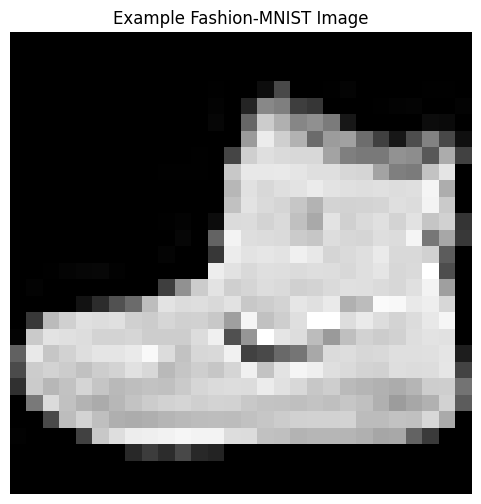

In [11]:
# Display a single example image

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(x_train[0].reshape(28,28), cmap="gray")
plt.title("Example Fashion-MNIST Image")
plt.axis("off")
plt.show()

# Visualizing Sample Training Images

I display a few sample images from the training dataset.

This helps verify that the images are loaded correctly and shows examples of the Fashion-MNIST classes.

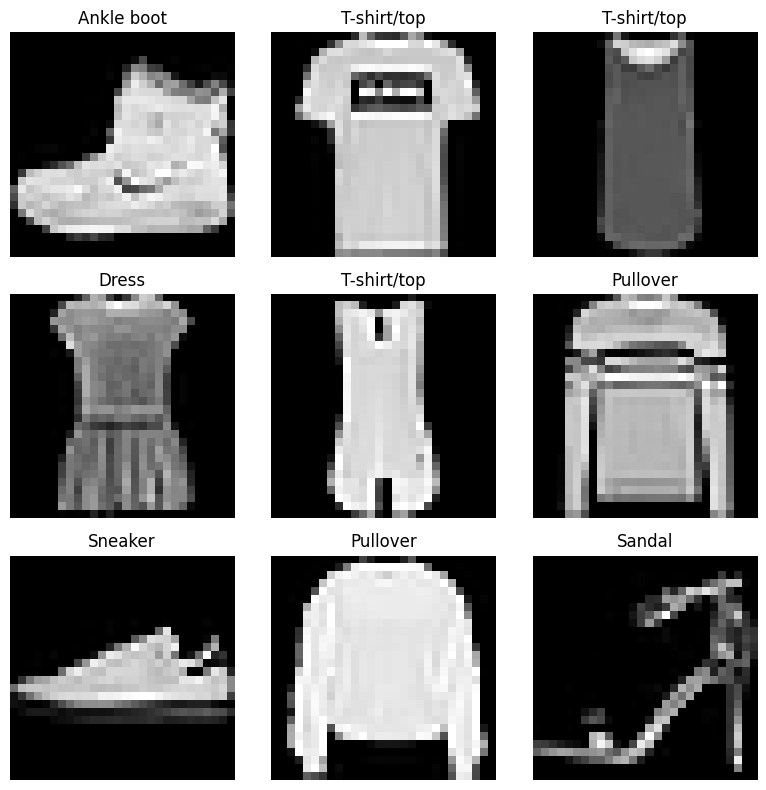

In [12]:
# Fashion-MNIST class names

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    
    image = x_train[i].reshape(28,28)
    label = y_train[i]
    
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Class Distribution of Training Data

This plot shows the number of images available for each clothing category in the Fashion-MNIST training dataset.

Each bar represents one class and displays the total number of images belonging to that class.

The dataset appears balanced, meaning that all classes contain approximately the same number of samples. Balanced datasets help prevent bias during training and allow the model to learn each class equally.

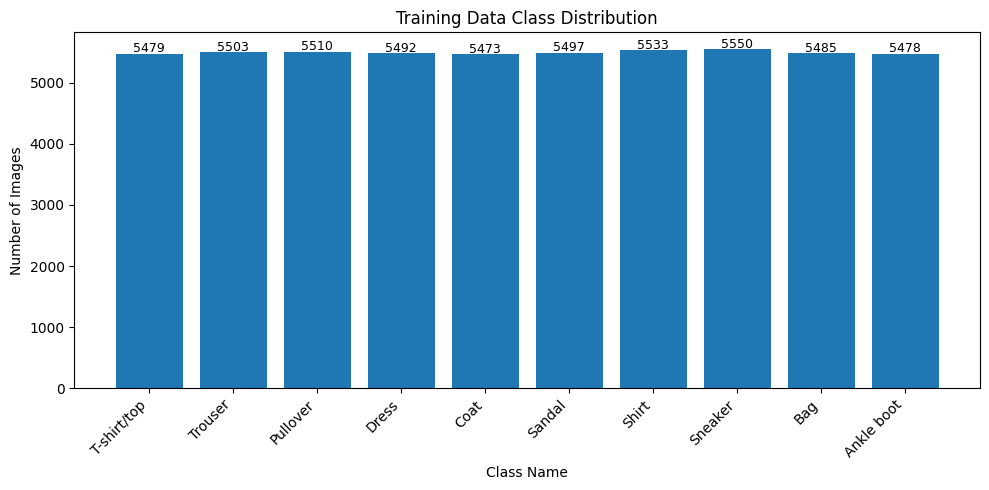

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Count number of samples per class
class_counts = np.bincount(y_train)

plt.figure(figsize=(10,5))

bars = plt.bar(class_names, class_counts)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20,
             str(height), ha='center', fontsize=9)

plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.title("Training Data Class Distribution")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
print("Final x_train shape:", x_train.shape)
print("Final x_val shape:", x_val.shape)

Final x_train shape: (55000, 28, 28, 1)
Final x_val shape: (5000, 28, 28, 1)


# Convolutional Neural Network (CNN)

I design a deep CNN to classify Fashion-MNIST images.

The architecture consists of:

- Convolution layers for feature extraction
- MaxPooling layers for spatial downsampling
- Batch Normalization to stabilize training
- Dropout layers to reduce overfitting
- Fully connected layers for classification

In [15]:
# BUILD CNN ARCHITECTURE

import tensorflow as tf
from tensorflow.keras import layers ,models ,initializers
from tensorflow.keras.regularizers import l2

# Use He initialization
initializer = tf.keras.initializers.HeNormal()

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(28,28,1)))

In [16]:
# Data Augmentation

model.add(layers.RandomFlip("horizontal"))
model.add(layers.RandomRotation(0.05))

In [17]:
# CONV1

model.add(layers.Conv2D(
    64, (3,3),
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0001),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [18]:
# POOL1

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.SpatialDropout2D(0.2))

In [19]:
# CONV2 

model.add(layers.Conv2D(
          128, (3,3),
          strides=1,
          padding="same",
          kernel_initializer=initializer,
          kernel_regularizer=l2(0.0001),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [20]:
# POOL2

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.SpatialDropout2D(0.2))

In [21]:
# CONV3 

model.add(layers.Conv2D(
    256, (3,3),
    strides=1,
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0001),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [22]:
# CONV4

model.add(layers.Conv2D(
    256, (3,3),
    strides=1,
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0001),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [23]:
# POOL3

model.add(layers.MaxPooling2D((2,2)))
model.add(layers.SpatialDropout2D(0.2))

In [24]:
# CONV5

model.add(layers.Conv2D(
    256, (3,3),
    strides=1,
    padding="same",
    kernel_initializer=initializer,
    kernel_regularizer=l2(0.0001),
))
model.add(layers.BatchNormalization())
model.add(layers.Activation("relu"))

In [25]:
model.add(layers.GlobalAveragePooling2D())

In [26]:
# FC1 

model.add(layers.Dense(
    512, 
    activation="relu"
))

model.add(layers.Dropout(0.5)) # reduce overfitting

In [27]:
model.add(layers.BatchNormalization())

In [28]:
# SOFTMAX (10 classes)

model.add(tf.keras.layers.Dense(
    10,
    activation="softmax"
))

In [29]:
# Show model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 14, 14, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 7, 7, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 3, 3, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 256)      │       590,08

 Total params: 1,692,426 (6.46 MB)

 Trainable params: 1,689,482 (6.44 MB)

 Non-trainable params: 2,944 (11.50 KB)

# Training Configuration

The model is compiled using:

- **Adam optimizer** for adaptive gradient updates
- **Sparse Categorical Crossentropy** loss for multi-class classification
- **Accuracy** as the evaluation metric

In [30]:
# compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
# Early stopping 

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [32]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [33]:
# Train model

history = model.fit(
    x_train,
    y_train,
    batch_size=512,
    epochs=70,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.6802 - loss: 1.0842 - val_accuracy: 0.7512 - val_loss: 1.0063 - learning_rate: 0.0010
Epoch 2/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8039 - loss: 0.7184 - val_accuracy: 0.8096 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 3/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8368 - loss: 0.6283 - val_accuracy: 0.8574 - val_loss: 0.5669 - learning_rate: 0.0010
Epoch 4/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8548 - loss: 0.5709 - val_accuracy: 0.8828 - val_loss: 0.4885 - learning_rate: 0.0010
Epoch 5/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8660 - loss: 0.5322 - val_accuracy: 0.8892 - val_loss: 0.4645 - learning_rate: 0.0010
Epoch 6/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8767 - loss: 0.4969 - val_accuracy: 0.8952 - val_loss: 0.4365 - learning_rate: 0.0010
Epoch 7/70
108/108 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8809 - loss: 0.

# Training Summary

I extract useful statistics from the training process:

- Total number of epochs trained
- Best validation accuracy achieved

In [34]:
# Total epochs actually trained
total_epochs_trained = len(history.history["loss"])

# Best validation accuracy
best_val_accuracy = max(history.history["val_accuracy"])

print("Total Epochs Trained:", total_epochs_trained)
print("Best Validation Accuracy:", best_val_accuracy)

Total Epochs Trained: 56
Best Validation Accuracy: 0.9419999718666077


# Learning Curve

The training and validation loss curves help analyze:

- Model convergence
- Overfitting behavior
- Training stability

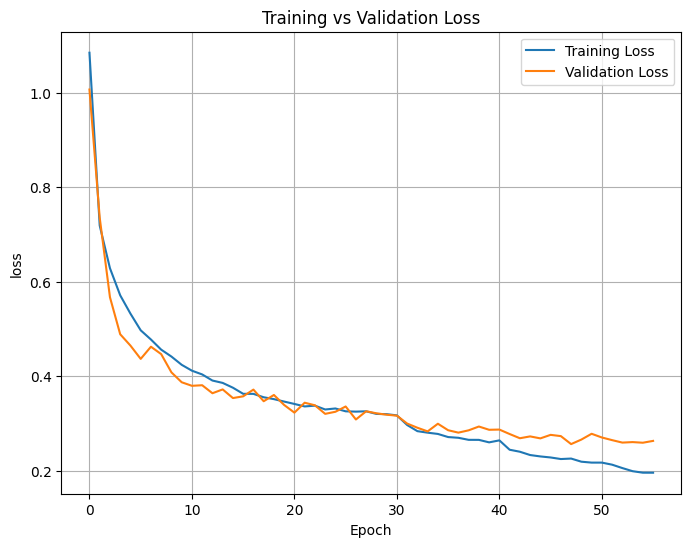

In [35]:
# PLOT LEARNING CURVE

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Training Loss
plt.plot(history.history["loss"], label="Training Loss")

# Validation Loss
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

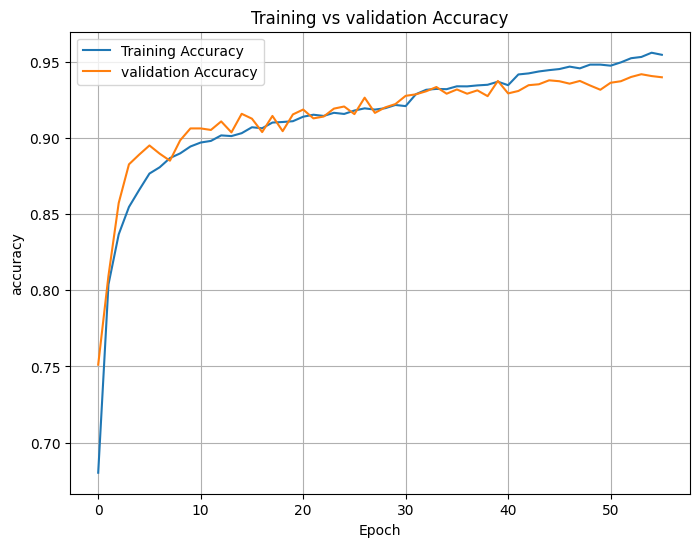

In [36]:
# Plot Accuracy Curve

plt.figure(figsize=(8,6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Model Evaluation

I evaluate the trained model on the validation dataset to measure final performance before generating predictions for the test dataset.

In [37]:
# VALIDATION PERFORMANCE

val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=1)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9376 - loss: 0.2562
Validation Accuracy: 0.9376000165939331
Validation Loss: 0.2561812400817871


In [38]:
# GENERATE KAGGLE SUBMISSION FILE

# Predict on test set
predictions = model.predict(x_test)

# Convert probabilities to class labels
pred_labels = np.argmax(predictions, axis=1)

# Create submission file using id column
submission = test_df[["id"]].copy()
submission["label"] = pred_labels

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
submission.csv created successfully!


In [39]:
# Save the trained model
model.save("fashion_cnn_model.h5")
print("✅ Model saved!")

✅ Model saved!


# Parameter Analysis

I compute:

- Total number of model parameters
- Parameters in convolution layers
- Parameters in fully connected layers

This helps analyze the complexity of the CNN architecture.

In [40]:
# PARAMETER COUNT

total_params = model.count_params()

conv_params = 0
fc_params = 0

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_params += layer.count_params()
    if isinstance(layer, tf.keras.layers.Dense):
        fc_params += layer.count_params()

print("Total Parameters:", total_params)
print("Convolution Layer Parameters:", conv_params)
print("fully Connected Layer Parameters:", fc_params)

Total Parameters: 1692426
Convolution Layer Parameters: 1549824
fully Connected Layer Parameters: 136714


# Neuron Count

The number of neurons in convolution and fully connected layers is calculated to understand the computational capacity of the network.

In [41]:
# NEURON COUNT

# Conv layer neurons
conv1_neurons = 64*28*28
conv2_neurons = 128*14*14
conv3_neurons = 256*7*7
conv4_neurons = 256*7*7
conv5_neurons = 256*3*3

total_conv_neurons = conv1_neurons + conv2_neurons + conv3_neurons + conv4_neurons + conv5_neurons

# Fully connected neurons
fc1_neurons = 512
softmax_neurons = 10

total_fc_neurons = fc1_neurons + softmax_neurons 

print("Total Conv Neurons:", total_conv_neurons)
print("Total FC Neurons:", total_fc_neurons)

Total Conv Neurons: 102656
Total FC Neurons: 522


# Convolution Filter Visualization

I visualize the filters learned by the first convolution layer.

These filters typically detect basic visual patterns such as edges, gradients, and textures.

Filter shape: (3, 3, 1, 64)


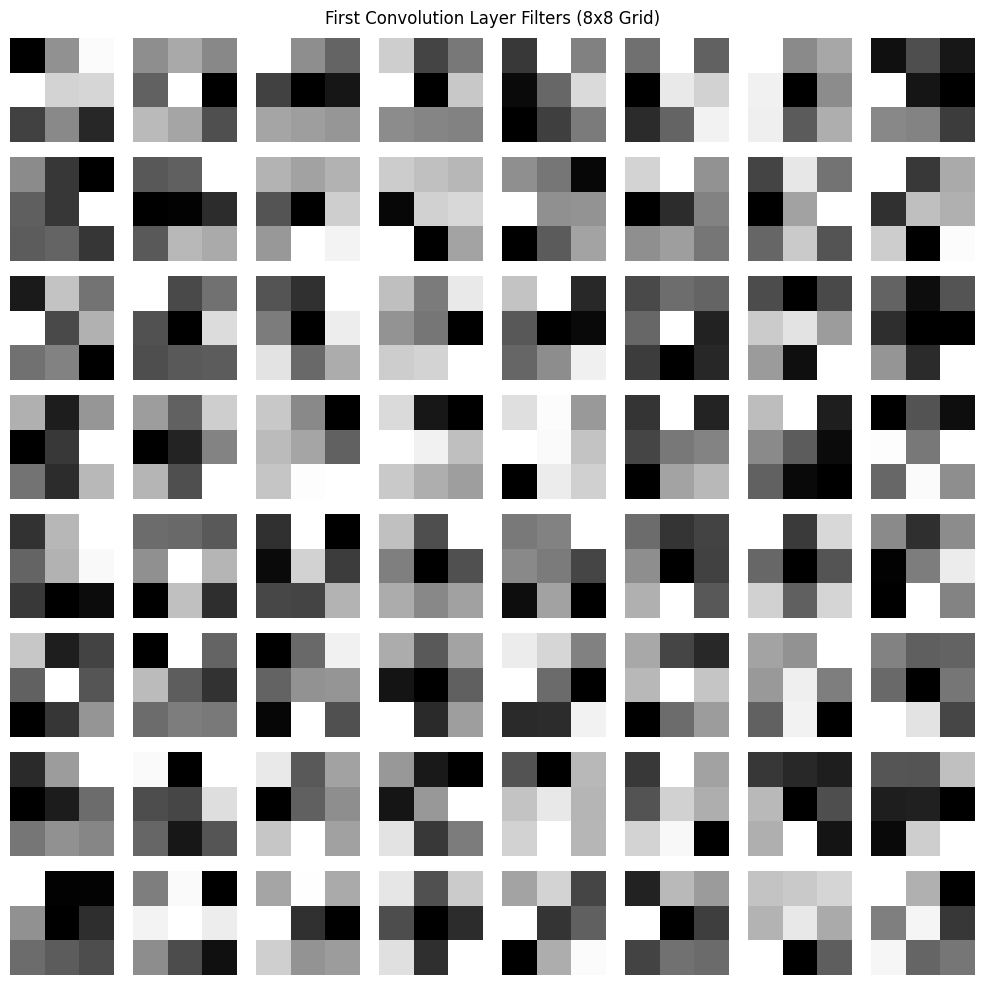

In [42]:
# VISUALIZE FIRST CONV LAYER FILTERS

first_conv_layer = None

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv_layer = layer
        break

filters, biases = first_conv_layer.get_weights()

print("Filter shape:", filters.shape)

# normalize
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

plt.figure(figsize=(10,10))

for i in range(64):

    plt.subplot(8,8,i+1)

    # grayscale filter
    filter_img = filters[:,:,0,i]

    plt.imshow(filter_img, cmap="gray")
    plt.axis("off")

plt.suptitle("First Convolution Layer Filters (8x8 Grid)")
plt.tight_layout()
plt.show()

## Selecting the Last Convolution Layer for Guided Backpropagation

For guided backpropagation, we need to analyze the **last convolutional layer** of the CNN.  
This layer contains high-level feature representations learned by the network.

Steps performed in this cell:

1. **Identify all convolution layers** in the model.
2. **Select the fifth convolution layer (CONV5)**, which is the final convolutional layer.
3. **Create a new model (`grad_model`)** that outputs the activations of this layer.

This allows us to compute gradients of the selected feature maps with respect to the input image, which helps visualize what parts of the image activate specific neurons.

In [43]:
conv_layers = [l for l in model.layers 
               if isinstance(l, tf.keras.layers.Conv2D)]
last_conv_layer = conv_layers[4]
print("using CONV5 layer:", last_conv_layer.name)

print("Using layer:", last_conv_layer.name)

# Create model that outputs activations of this layer
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=last_conv_layer.output
)

using CONV5 layer: conv2d_4
Using layer: conv2d_4


# Guided Backpropagation

Guided backpropagation is used to visualize which regions of the input image strongly activate specific neurons in the convolutional layer.

This helps interpret what features the CNN has learned.

In [44]:
# Guided Backprop Function

@tf.function
def guided_backprop(input_image, filter_index):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        activations = grad_model(input_image)
        loss = tf.reduce_mean(activations[:, :, :, filter_index])
    
    gradients = tape.gradient(loss, input_image)

    # Guided Backprop rule:
    # Only allow positive gradients
    positive_gradients = tf.cast(gradients > 0, tf.float32)

    guided_gradients = positive_gradients * gradients

    return guided_gradients

## Generate Visualizations

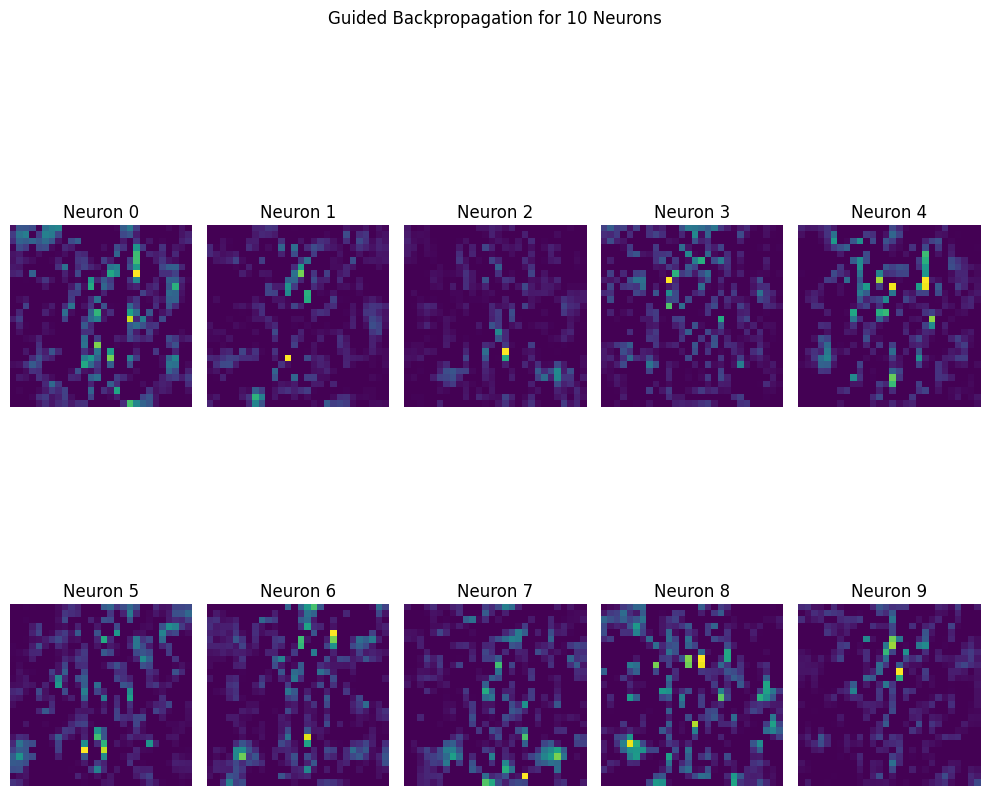

In [45]:
# Use first validation image
input_image = tf.convert_to_tensor(x_val[0:1])

plt.figure(figsize=(10,10))

for i in range(10):
    guided_grads = guided_backprop(input_image, i)

    # Normalize for display
    guided_grads = guided_grads.numpy()[0]
    guided_grads = (guided_grads - guided_grads.min()) / \
               (guided_grads.max() - guided_grads.min() + 1e-8)

    plt.subplot(2,5,i+1)
    plt.imshow(guided_grads)
    plt.title(f"Neuron {i}")
    plt.axis("off")

plt.suptitle("Guided Backpropagation for 10 Neurons")
plt.tight_layout()
plt.show()

## Supporting Observations

In [46]:
print("Total Epochs Trained:", len(history.history["loss"]))
print("Best Train Accuracy:", max(history.history["accuracy"]))
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))

Total Epochs Trained: 56
Best Train Accuracy: 0.9561272859573364
Best Validation Accuracy: 0.9419999718666077


# Model Performance Evaluation

In this section I evaluate the trained CNN model using the validation dataset.

The evaluation includes:

- Final training accuracy
- Best validation accuracy
- Confusion matrix
- Classification report

These metrics help analyze the performance of the model.

In [47]:
# Import evaluation libraries

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

## Accuracy Evaluation

I compute the following metrics:

- Final training accuracy
- Best training accuracy during training
- Validation accuracy
- Best validation accuracy achieved

In [48]:
# Final Training Accuracy
final_train_acc = history.history["accuracy"][-1]
best_train_acc = max(history.history["accuracy"])

# Validation Accuracy
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)

# Best Validation Accuracy During Training
best_val_acc = max(history.history["val_accuracy"])

print("Final Training Accuracy:", final_train_acc)
print("Best Training Accuracy:", best_train_acc)
print("Validation Accuracy (Evaluate):", val_acc)
print("Best Validation Accuracy:", best_val_acc)

Final Training Accuracy: 0.954763650894165
Best Training Accuracy: 0.9561272859573364
Validation Accuracy (Evaluate): 0.9383999705314636
Best Validation Accuracy: 0.9419999718666077


## Confusion Matrix

The confusion matrix shows how well the model predicts each class.

Correct predictions appear along the diagonal while incorrect predictions appear in other cells.

In [49]:
# Generate predictions on validation set

val_predictions = model.predict(x_val)
val_pred_labels = np.argmax(val_predictions, axis=1)

cm = confusion_matrix(y_val, val_pred_labels)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


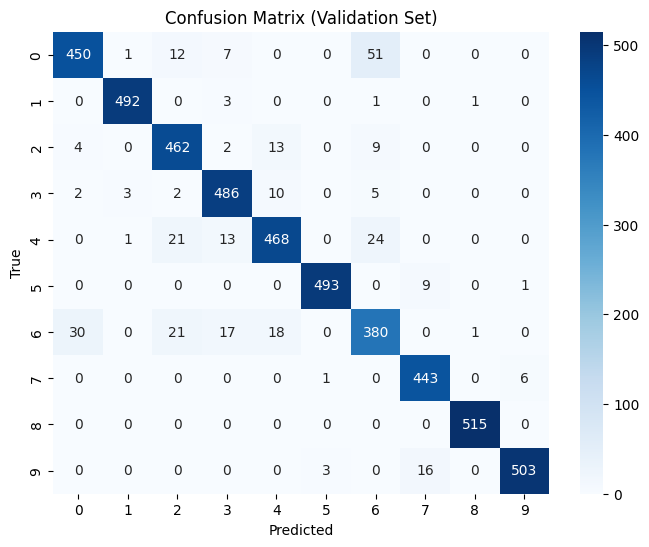

In [50]:
# Plot Confusion Matrix

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation Set)")

plt.show()

## Classification Report

The classification report provides detailed performance metrics for each class including:

- Precision
- Recall
- F1-score

These metrics help understand how well the model performs on individual classes.

In [51]:
print("\nClassification Report:\n")
print(classification_report(y_val, val_pred_labels))


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       521
           1       0.99      0.99      0.99       497
           2       0.89      0.94      0.92       490
           3       0.92      0.96      0.94       508
           4       0.92      0.89      0.90       527
           5       0.99      0.98      0.99       503
           6       0.81      0.81      0.81       467
           7       0.95      0.98      0.97       450
           8       1.00      1.00      1.00       515
           9       0.99      0.96      0.97       522

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



# Project Conclusion

This project implemented a Convolutional Neural Network (CNN) to classify images from the Fashion-MNIST dataset, which contains grayscale images of clothing items belonging to 10 categories.

### Key Highlights
- Successfully built a deep CNN architecture with 5 convolutional layers.
- Applied Batch Normalization, Spatial Dropout, and L2 regularization to improve generalization and reduce overfitting.
- Used data augmentation techniques such as random flipping and rotation to improve model robustness.
- Implemented Early Stopping and Learning Rate Scheduling for efficient training.
- Visualized filters and guided backpropagation to interpret learned features.

### Model Performance
- The model achieved high training accuracy and strong validation performance.
- The dataset distribution was balanced across all classes, helping prevent bias during training.
- The learning curves demonstrated stable convergence and controlled overfitting.

### Model Analysis
- Filter visualization showed that early layers learn basic edge and texture features.
- Guided backpropagation highlighted important regions of the input image that influence predictions.

### Final Outcome
The CNN model effectively learned meaningful representations of Fashion-MNIST images and demonstrated strong classification performance. Overall, the project successfully illustrates how deep convolutional networks can be applied to image classification tasks while also providing insight into the internal behavior of the model through visualization techniques.